### Notebook to generate humidity-sorted cross sections from soundings.

James Ruppert  
jruppert@ou.edu  
5/7/25

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rc
import matplotlib.ticker as ticker
from thermo_functions import *
from orcestra_read_data import *
from time_series_diag import *
import pandas as pd
import seaborn as sns
from vertical_int import *
from dynamo_read_data import *

### Read in data

#### Data from IPFS server

In [2]:
# Meteor soundings
snd_meteor = read_soundings(platform='RV_Meteor', ascent=0)
snd_vars = list(snd_meteor.keys())[2:] # retain only 2-d variables in list

# HALO dropsondes
snd_halo_sonde = read_halo_soundings_lev3()
nt_halo = len(snd_halo_sonde['times'])
min_pres_halo = np.full(nt_halo, np.nan)
for isnd in range(nt_halo):
    min_pres_halo[isnd] = np.nanmin(snd_halo_sonde['p'][isnd,:]*1e-2) # Pa --> hPa
# HALO circles
snd_halo_circ = read_halo_soundings_lev4()

# BCO soundings
snd_bco = read_soundings(platform='BCO')

# DYNAMO soundings
snd_dyn = read_dynamo_soundings()

# Mask soundings that don't reach 100 hPa
p_threshold = 100 # hPa
snd_meteor, min_pres_meteor = mask_soundings(snd_meteor, p_threshold=p_threshold)
# snd_halo, min_pres_halo = mask_soundings(snd_halo, p_threshold=p_threshold)
snd_bco, min_pres_bco = mask_soundings(snd_bco, p_threshold=p_threshold)
min_pres_dyn={}
for idyn in snd_dyn.keys():
    snd_dyn[idyn], min_pres_dyn[idyn] = mask_soundings(snd_dyn[idyn], p_threshold=p_threshold)

/Users/jamesruppert/miniforge3/envs/plotting/lib/python3.11/site-packages/xarray/conventions.py:204: SerializationWarning: variable 'T' has multiple fill values {np.float32(-999.0), np.float32(-9999.0)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/Users/jamesruppert/miniforge3/envs/plotting/lib/python3.11/site-packages/xarray/conventions.py:204: SerializationWarning: variable 'Td' has multiple fill values {np.float32(-999.0), np.float32(-9999.0)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/Users/jamesruppert/miniforge3/envs/plotting/lib/python3.11/site-packages/xarray/conventions.py:204: SerializationWarning: variable 'wind_spd' has multiple fill values {np.float32(-999.0), np.float32(-9999.0)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/Users/jamesruppert/miniforge3/envs/plotting/lib/python3.11/site-packages/xarray/conventions.py:204: SerializationWarning: variable 'wind_dir' has multiple fill 

In [3]:
# Concatenate BCO, HALO, and Meteor soundings
# nzhalo = snd_halo['hght'].shape[0]
# nthalo = len(snd_halo['time'])
# nzmeteor = snd_meteor['hght'].shape[0]
# nans = np.full((nthalo, nzmeteor-nzhalo), np.nan)
# snd_concat = {}
# snd_concat['time'] = np.concatenate((snd_meteor['times'], snd_bco['times'], snd_halo['time']), axis=0)
# snd_concat['hght'] = snd_meteor['hght']
# for key in ['p', 'tmpk', 'mr']:
#     snd_concat[key] = np.concatenate((snd_meteor[key], snd_bco[key], np.append(snd_halo[key], nans, axis=1)), axis=0)

### Vertically integrate water vapor

In [4]:
# CWV aka IWV aka PW
snd_meteor['cwv'] = vert_integral(snd_meteor)
# snd_concat['cwv'] = vert_integral(snd_concat)
snd_halo_sonde['cwv'] = vert_integral(snd_halo_sonde)
snd_halo_circ['cwv'] = vert_integral(snd_halo_circ)
snd_bco['cwv'] = vert_integral(snd_bco)
for idyn in snd_dyn.keys():
    snd_dyn[idyn]['cwv'] = vert_integral(snd_dyn[idyn])

### Bin data by Variable

In [5]:
def run_binning(binvar, zvar, vartobin):
    nbins = len(binvar['bin_edges'])-1
    nz = zvar['zvar'].shape[0]
    binned_vars = {}
    binnedvar = np.full((nbins, nz), np.nan)
    for ibin in range(nbins):
        idx_ibin = np.where((binvar['binvar'] >= binvar['bin_edges'][ibin]) & (binvar['binvar'] < binvar['bin_edges'][ibin+1]))[0]
        binnedvar[ibin,:] = np.nanmean(vartobin[idx_ibin, :], axis=0)
    # Smooth the vertical dimension
    var0 = pd.DataFrame(binnedvar.transpose())
    nz_smooth = int(0.15 / (zvar['zvar'][1] - zvar['zvar'][0]))
    print('nz_smooth', nz_smooth)
    var0 = var0.rolling(window=nz_smooth, center=True, closed='both').mean()
    binned_vars = {
        # 'binnedvar': binnedvar,
        'binnedvar': var0.transpose().values,
    }
    return binned_vars

def get_binvar(sounding):
    # Bin settings
    binvar_tag = 'cwv'
    binvar_label = 'CWV [kg/m$^2$]'
    xmin = 30
    xmax = 70
    dx = 2
    bin_edges = np.arange(xmin-dx*0.5, xmax+dx*1.5, dx)
    binvar = {
        'bin_edges': bin_edges,
        'binvar': sounding['cwv'],
        'binvar_tag': binvar_tag,
        'binvar_label': binvar_label
    }
    return binvar

---
### Plotting routines

#### Plotting functions

In [6]:
font = {'family' : 'sans-serif',
        'weight' : 'normal',
        'size'   : 12}

rc('font', **font)

sns.set_theme(style="darkgrid", rc={'xtick.bottom': True, 'ytick.left': True,})
# sns.set_theme(style="ticks", rc={'xtick.bottom': True, 'ytick.left': True})#, "axes.spines.right": False, "axes.spines.top": False})
# sns.set_theme(style="dark")

#### Exclude Mindelo data

In [7]:
# # Select times after 16 Aug 2024
# t_start = np.datetime64('2024-08-16T08:00:00')
# t_ind_snd = np.where(soundings['times'] >= t_start)[0]
# t_ind_rdm = np.where(times_rdm >= t_start)[0]
# t_ind_photom = np.where(np.array(photom['Date(dd:mm:yyyy)']) >= t_start)[0]
# t_ind_gps = np.where(times_gps >= t_start)[0]
# t_ind_era5v1 = np.where(times_era5 >= t_start)[0]
# t_ind_era5v2 = np.where(times_sonde_era5 >= t_start)[0]

In [8]:
def plot_binned_var(binvar, zvar, binned_var, title, vmin=None, vmax=None, zmax=None, cmap=None, cont_var=None):
    if cmap is None:
        cmap = 'BrBG'
    norm = None
    sizex = 8
    sizey = 5
    fig, ax = plt.subplots(figsize=(sizex, sizey))#, layout='tight')#, squeeze=0.1)
    fig_title = title
    fig.suptitle(fig_title, fontsize=14)
    ax.set_xlabel(binvar['binvar_label'], fontsize=12)
    ax.set_ylabel(zvar['zvar_label'], fontsize=12)
    if zmax is None:
        zmax = zvar['zmax']
    ax.set_ylim(np.nanmin(zvar['zvar']), zmax)
    im = ax.pcolormesh(binvar['bin_edges'], zvar['zvar'], np.transpose(binned_var[:,:-1]), cmap=cmap, alpha=0.8, norm=norm,
                       zorder=2, vmin=vmin, vmax=vmax, shading='auto')
    # Overlay contour field
    if cont_var is not None:
        cmax=100
        delta = cmax/10
        clevs = np.arange(-cmax, cmax+delta, delta)
        cont = ax.contour(binvar['bin_edges'][:-1], zvar['zvar'], np.transpose(cont_var), levels=clevs, colors='k', linewidths=0.5, alpha=0.8)
        plt.clabel(cont, inline=True, fontsize=8)
    fig.colorbar(im, ax=ax, shrink=0.75, ticks=ticker.AutoLocator(), pad=0.02)#, label=units_var
    plt.show()
    return None

nz_smooth 15


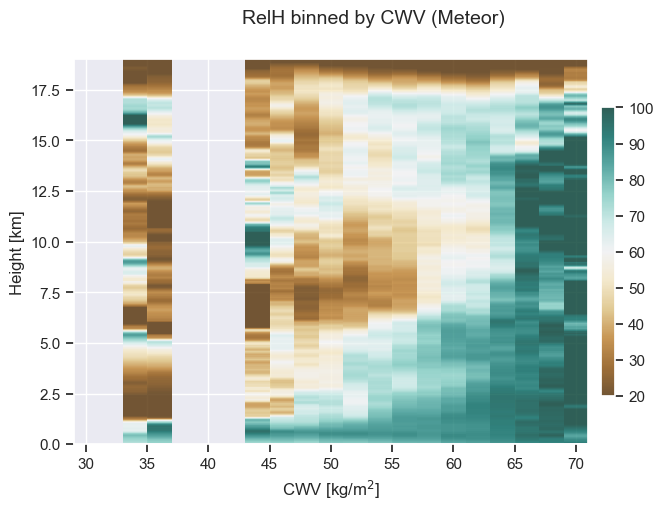

nz_smooth 15


/var/folders/9x/209ltwrn2b359nrrh4638hv40000gp/T/ipykernel_28767/3591022128.py:24: RuntimeWarning: Mean of empty slice
  binned_vars_meteor['binnedvar'] -= (np.nanmean(binned_vars_meteor['binnedvar'], axis=0))[np.newaxis,:]


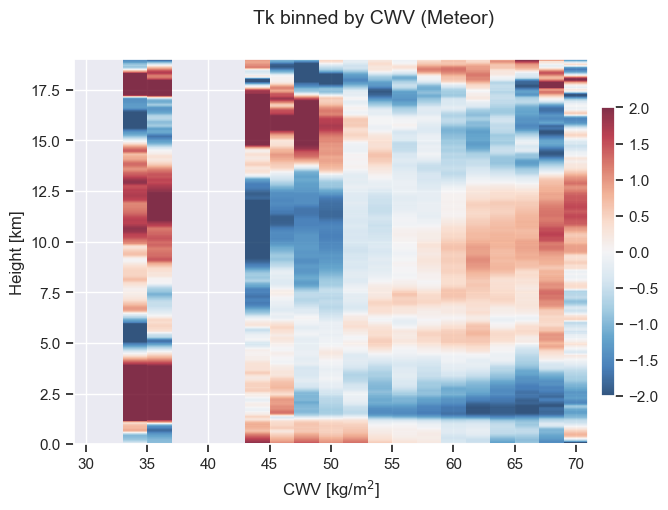

nz_smooth 15


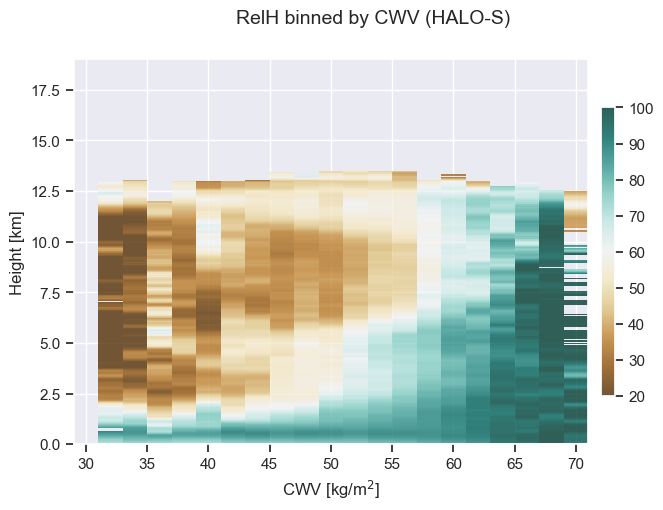

nz_smooth 15


/var/folders/9x/209ltwrn2b359nrrh4638hv40000gp/T/ipykernel_28767/1307202787.py:8: RuntimeWarning: Mean of empty slice
  binnedvar[ibin,:] = np.nanmean(vartobin[idx_ibin, :], axis=0)
/var/folders/9x/209ltwrn2b359nrrh4638hv40000gp/T/ipykernel_28767/3591022128.py:52: RuntimeWarning: Mean of empty slice
  binned_vars_halo_sonde['binnedvar'] -= (np.nanmean(binned_vars_halo_sonde['binnedvar'], axis=0))[np.newaxis,:]


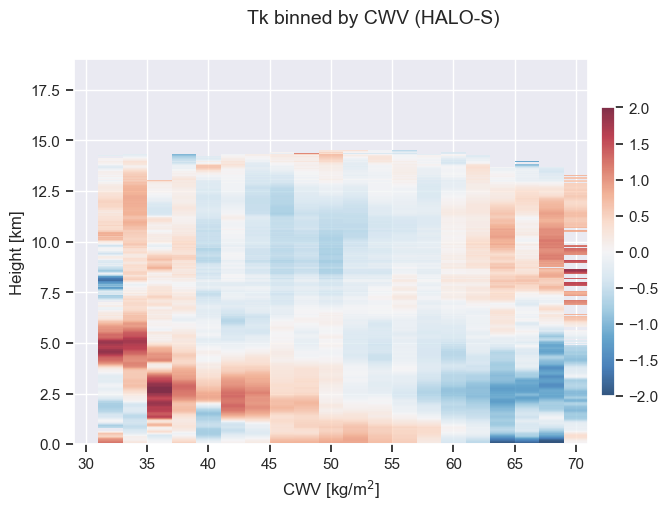

nz_smooth 15
nz_smooth 15


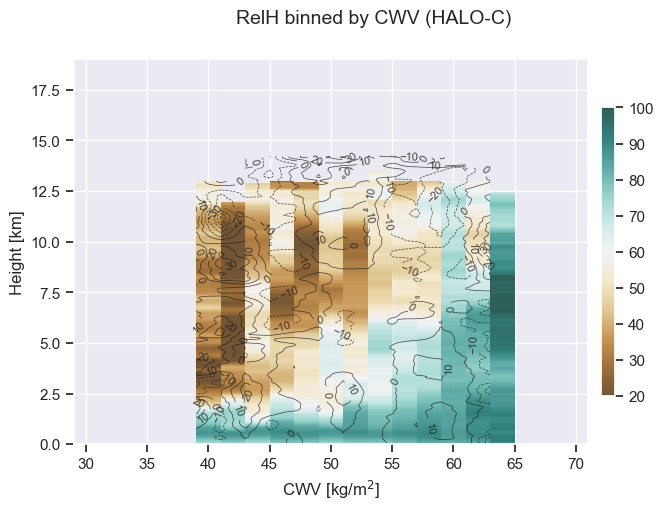

nz_smooth 15


/var/folders/9x/209ltwrn2b359nrrh4638hv40000gp/T/ipykernel_28767/3591022128.py:83: RuntimeWarning: Mean of empty slice
  binned_vars_halo_circ['binnedvar'] -= (np.nanmean(binned_vars_halo_circ['binnedvar'], axis=0))[np.newaxis,:]


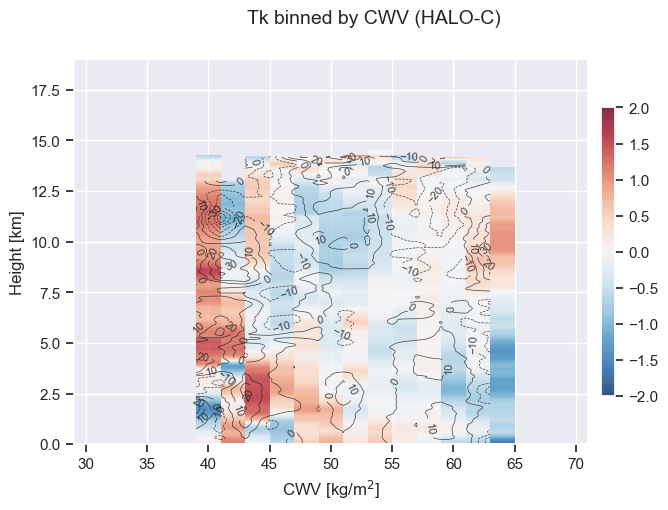

nz_smooth 15


/var/folders/9x/209ltwrn2b359nrrh4638hv40000gp/T/ipykernel_28767/1307202787.py:8: RuntimeWarning: Mean of empty slice
  binnedvar[ibin,:] = np.nanmean(vartobin[idx_ibin, :], axis=0)


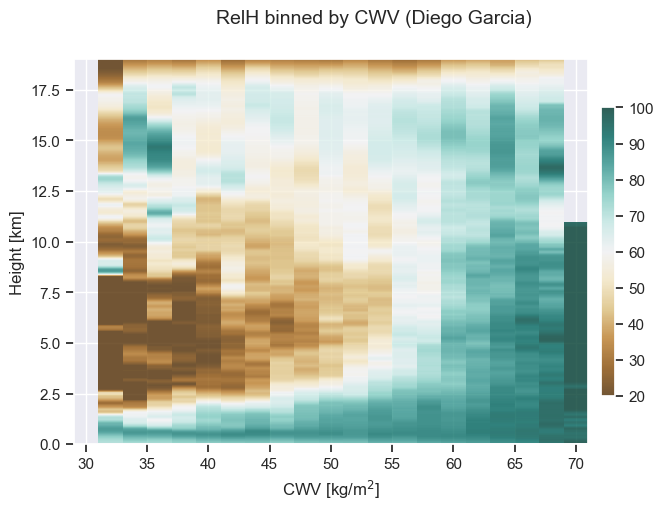

nz_smooth 15


/var/folders/9x/209ltwrn2b359nrrh4638hv40000gp/T/ipykernel_28767/1307202787.py:8: RuntimeWarning: Mean of empty slice
  binnedvar[ibin,:] = np.nanmean(vartobin[idx_ibin, :], axis=0)
/var/folders/9x/209ltwrn2b359nrrh4638hv40000gp/T/ipykernel_28767/3591022128.py:137: RuntimeWarning: Mean of empty slice
  binned_vars_meteor['binnedvar'] -= (np.nanmean(binned_vars_meteor['binnedvar'], axis=0))[np.newaxis,:]


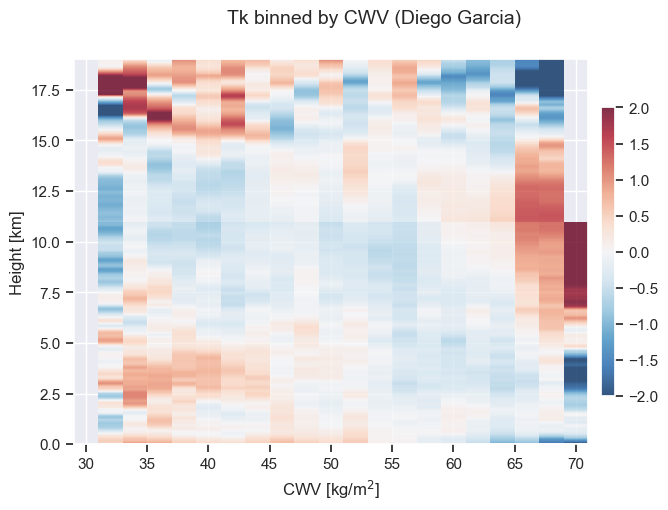

In [9]:
################################################################################
# Meteor

zvar={}
zvar['zvar'] = snd_meteor['hght']*1e-3 # m --> km
zvar['zvar_label'] = 'Height [km]'

# Relative humidity
# var_label = 'RelH [%]'
title = 'RelH binned by CWV (Meteor)'
vartobin = calc_relh(snd_meteor['mr'],snd_meteor['p'],snd_meteor['tmpk'],ice=True)
binvar  = get_binvar(snd_meteor)
binned_vars_meteor = run_binning(binvar, zvar, vartobin)

plot_binned_var(binvar, zvar, binned_vars_meteor['binnedvar'], title=title,
                vmin=20, vmax=100, zmax=19, cmap='BrBG')

# Temperature
# var_label = 'Temp [K]'
title = 'Tk binned by CWV (Meteor)'
vartobin = snd_meteor['tmpk']
binvar  = get_binvar(snd_meteor)
binned_vars_meteor = run_binning(binvar, zvar, vartobin)
binned_vars_meteor['binnedvar'] -= (np.nanmean(binned_vars_meteor['binnedvar'], axis=0))[np.newaxis,:]

plot_binned_var(binvar, zvar, binned_vars_meteor['binnedvar'], title=title,
                vmin=-2, vmax=2, zmax=19, cmap='RdBu_r')

################################################################################
# HALO-S

zvar={}
zvar['zvar'] = snd_halo_sonde['hght']*1e-3 # m --> km
zvar['zvar_label'] = 'Height [km]'

# Relative humidity
# var_label = 'RelH [%]'
title = 'RelH binned by CWV (HALO-S)'
vartobin = calc_relh(snd_halo_sonde['mr'],snd_halo_sonde['p'],snd_halo_sonde['tmpk'],ice=True)
binvar  = get_binvar(snd_halo_sonde)
binned_vars_halo_sonde = run_binning(binvar, zvar, vartobin)

plot_binned_var(binvar, zvar, binned_vars_halo_sonde['binnedvar'], title=title,
                vmin=20, vmax=100, zmax=19, cmap='BrBG')

# Temperature
# var_label = 'Temp [K]'
title = 'Tk binned by CWV (HALO-S)'
vartobin = snd_halo_sonde['tmpk']
binvar  = get_binvar(snd_halo_sonde)
binned_vars_halo_sonde = run_binning(binvar, zvar, vartobin)
binned_vars_halo_sonde['binnedvar'] -= (np.nanmean(binned_vars_halo_sonde['binnedvar'], axis=0))[np.newaxis,:]

plot_binned_var(binvar, zvar, binned_vars_halo_sonde['binnedvar'], title=title,
                vmin=-2, vmax=2, zmax=19, cmap='RdBu_r')

################################################################################
# HALO-C

zvar={}
zvar['zvar'] = snd_halo_circ['hght']*1e-3 # m --> km
zvar['zvar_label'] = 'Height [km]'

# Relative humidity
# var_label = 'RelH [%]'
title = 'RelH binned by CWV (HALO-C)'
vartobin = calc_relh(snd_halo_circ['mr'],snd_halo_circ['p'],snd_halo_circ['tmpk'],ice=True)
binvar  = get_binvar(snd_halo_circ)
binned_vars_halo_circ = run_binning(binvar, zvar, vartobin)
# Get vertical motion
# binned_vertm = run_binning(binvar, zvar, snd_halo_circ['w']*1e3) # m/s
binned_vertm = run_binning(binvar, zvar, snd_halo_circ['vor']*1e6) # /s

plot_binned_var(binvar, zvar, binned_vars_halo_circ['binnedvar'], title=title,
                vmin=20, vmax=100, zmax=19, cmap='BrBG', cont_var=binned_vertm['binnedvar'])

# Temperature
# var_label = 'Temp [K]'
title = 'Tk binned by CWV (HALO-C)'
vartobin = snd_halo_circ['tmpk']
binvar  = get_binvar(snd_halo_circ)
binned_vars_halo_circ = run_binning(binvar, zvar, vartobin)
binned_vars_halo_circ['binnedvar'] -= (np.nanmean(binned_vars_halo_circ['binnedvar'], axis=0))[np.newaxis,:]

plot_binned_var(binvar, zvar, binned_vars_halo_circ['binnedvar'], title=title,
                vmin=-2, vmax=2, zmax=19, cmap='RdBu_r', cont_var=binned_vertm['binnedvar'])

################################################################################
# Meteor + BCO + HALO

# # Relative humidity
# # var_label = 'RelH [%]'
# title = 'RelH binned by CWV (ORCESTRA)'
# vartobin = calc_relh(snd_concat['mr'],snd_concat['p'],snd_concat['tmpk'],ice=True)
# binvar  = get_binvar(snd_concat)
# binned_vars_meteor = cwv_binning(binvar, zvar, vartobin)

# plot_binned_var(binvar, zvar, binned_vars_meteor['binnedvar'], title=title,
#                 vmin=20, vmax=100, zmax=19, cmap='BrBG')

################################################################################
# DYNAMO

sounding = snd_dyn['Diego Garcia, British Indian Ocean Territory']

zvar={}
zvar['zvar'] = snd_meteor['hght']*1e-3 # m --> km
zvar['zvar_label'] = 'Height [km]'

# Vertically interpolate onto height grid
sounding_z = {}
dims = (sounding['p'].shape[0], zvar['zvar'].shape[0])
sounding_z['p'] = np.full(dims, np.nan)
sounding_z['tmpk'] = np.full(dims, np.nan)
sounding_z['mr'] = np.full(dims, np.nan)
for it in range(sounding['p'].shape[0]):
    sounding_z['p'][it,:] = np.interp(snd_meteor['hght'], sounding['hght'][it,:], sounding['p'][it,:])
    sounding_z['tmpk'][it,:] = np.interp(snd_meteor['hght'], sounding['hght'][it,:], sounding['tmpk'][it,:])
    sounding_z['mr'][it,:] = np.interp(snd_meteor['hght'], sounding['hght'][it,:], sounding['mr'][it,:])

# Relative humidity
# var_label = 'RelH [%]'
title = 'RelH binned by CWV (Diego Garcia)'
vartobin = calc_relh(sounding_z['mr'],sounding_z['p'],sounding_z['tmpk'],ice=True)
binvar  = get_binvar(sounding)
binned_vars_meteor = run_binning(binvar, zvar, vartobin)

plot_binned_var(binvar, zvar, binned_vars_meteor['binnedvar'], title=title,
                vmin=20, vmax=100, zmax=19, cmap='BrBG')

# Temperature
# var_label = 'Temp [K]'
title = 'Tk binned by CWV (Diego Garcia)'
vartobin = sounding_z['tmpk']
binvar  = get_binvar(sounding)
binned_vars_meteor = run_binning(binvar, zvar, vartobin)
binned_vars_meteor['binnedvar'] -= (np.nanmean(binned_vars_meteor['binnedvar'], axis=0))[np.newaxis,:]

plot_binned_var(binvar, zvar, binned_vars_meteor['binnedvar'], title=title,
                vmin=-2, vmax=2, zmax=19, cmap='RdBu_r')